## Exploratory Data Analysis (EDA)
Our forecasting pipeline begins with a comprehensive Exploratory Data Analysis (EDA) of the tabular feature set. The primary objective is to model baseline load dynamics and engineer a system capable of predicting electricity demand with a 24-hour horizon. To ensure robust performance  during critical demand surges, the model's accuracy is benchmarked using Root Mean Square Error (RMSE), Mean Absolute Percentage Error (MAPE), and Peak MAPE.

In [9]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from data.utils import plot_features_dual_axis
from data.utils import plot_train_test_distributions

RANDOM_STATE = 42
TRAIN_END = "2025-08-04 23:00:00"   # inclusive
TEST_START = "2025-08-05 00:00:00"


In [11]:
df = pd.read_csv("../data/raw/ercot_south_central_raw.csv")
print("data shape:", df.shape)
df.head(2)

data shape: (92879, 9)


,timestamp,timestamp_central,actual_load_mw,temp_c,humidity_pct,precip_mm,tmax,tmin,tavg
0,2016-01-01 00:00:00+00:00,2015-12-31 18:00:00-06:00,6848.58,10.902697,60.428911,0.0,10.902697,9.96666,10.465636
1,2016-01-01 01:00:00+00:00,2015-12-31 19:00:00-06:00,6599.73,10.714651,60.498833,0.0,10.902697,9.96666,10.465636


In [12]:
df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp_central"] = pd.to_datetime(df["timestamp_central"])
df=df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)
print(df["timestamp"].min(), "→", df["timestamp"].max())
df.head()


(92879, 9)
2016-01-01 00:00:00+00:00 → 2026-08-05 23:00:00+00:00


C:\Users\hp\AppData\Local\Temp\ipykernel_29316\3556016570.py:3: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["timestamp_central"] = pd.to_datetime(df["timestamp_central"])


,timestamp,timestamp_central,actual_load_mw,temp_c,humidity_pct,precip_mm,tmax,tmin,tavg
0,2016-01-01 00:00:00+00:00,2015-12-31 18:00:00-06:00,6848.58,10.902697,60.428911,0.0,10.902697,9.96666,10.465636
1,2016-01-01 01:00:00+00:00,2015-12-31 19:00:00-06:00,6599.73,10.714651,60.498833,0.0,10.902697,9.96666,10.465636
2,2016-01-01 02:00:00+00:00,2015-12-31 20:00:00-06:00,6357.69,10.595334,61.405271,0.0,10.902697,9.96666,10.465636
3,2016-01-01 03:00:00+00:00,2015-12-31 21:00:00-06:00,6120.83,10.409551,61.834183,0.0,10.902697,9.96666,10.465636
4,2016-01-01 04:00:00+00:00,2015-12-31 22:00:00-06:00,5882.63,10.204923,62.263094,0.0,10.902697,9.96666,10.465636


In [13]:
df_train = df[df["timestamp"] <= TRAIN_END].reset_index(drop=True)
df_test  = df[df["timestamp"] >= TEST_START].reset_index(drop=True)

print(f"Train: {len(df_train):,} rows | {df_train['timestamp'].min()} → {df_train['timestamp'].max()}")
print(f"Test:  {len(df_test):,} rows | {df_test['timestamp'].min()} → {df_test['timestamp'].max()}")


Train: 84,095 rows | 2016-01-01 00:00:00+00:00 → 2025-08-04 23:00:00+00:00
Test:  8,784 rows | 2025-08-05 00:00:00+00:00 → 2026-08-05 23:00:00+00:00


### Basic EDA
For basic EDA, we view the histogram of the target. Next we view the relationship between each feature and target. Also we view each features histogram, unique value count, and nan count. For each feature we determinr if its categorical or numeric 


<function matplotlib.pyplot.show(close=None, block=None)>

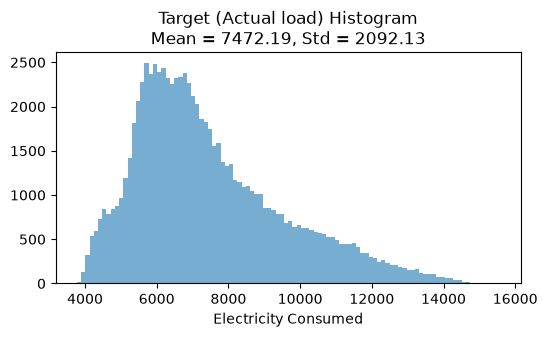

In [15]:
plt.figure(figsize=(6,3))
m,s = df_train["actual_load_mw"].mean(), df_train["actual_load_mw"].std()
plt.hist(df_train["actual_load_mw"],bins=100, alpha=0.6)
plt.title(f"Target (Actual load) Histogram\nMean = {m:.2f}, Std = {s:.2f}")
plt.xlabel("Electricity Consumed")
plt.show



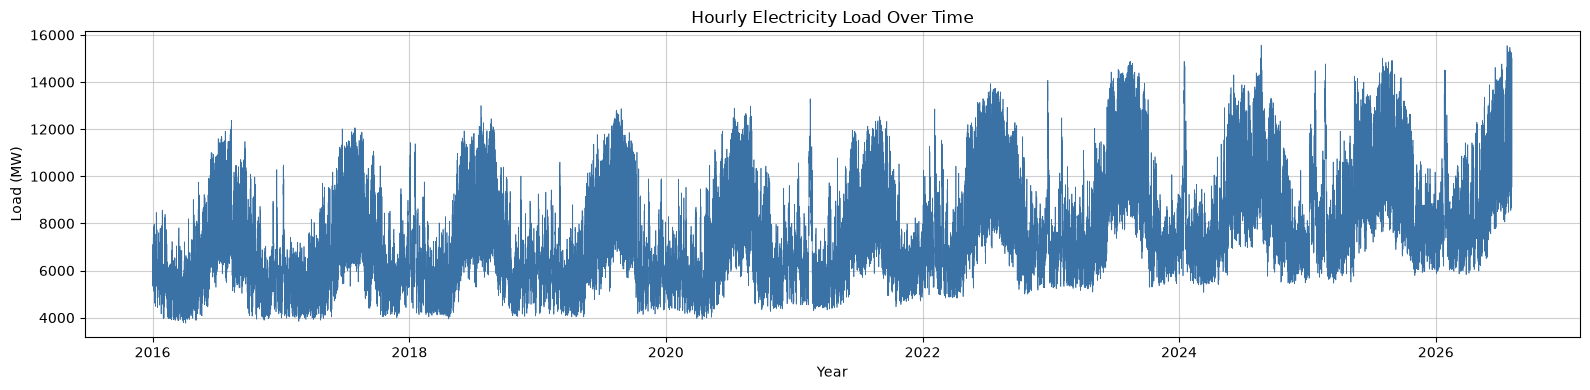

In [18]:
# 1. Set up a wide canvas to stretch the years out cleanly
plt.figure(figsize=(16, 4))

# 2. Plot the line chart
# Using a very thin linewidth (0.5) is crucial here so the density 
# of the hourly data doesn't just turn into a solid block of color
plt.plot(df["timestamp"], df["actual_load_mw"], linewidth=0.5, color="#3b72a6")

# 3. Add titles and labels matching the context
plt.title("Hourly Electricity Load Over Time")
plt.xlabel("Year")
plt.ylabel("Load (MW)")

# 4. Add the background grid for readability
plt.grid(True, alpha=0.6)

# 5. Render the plot
plt.tight_layout()
plt.show()

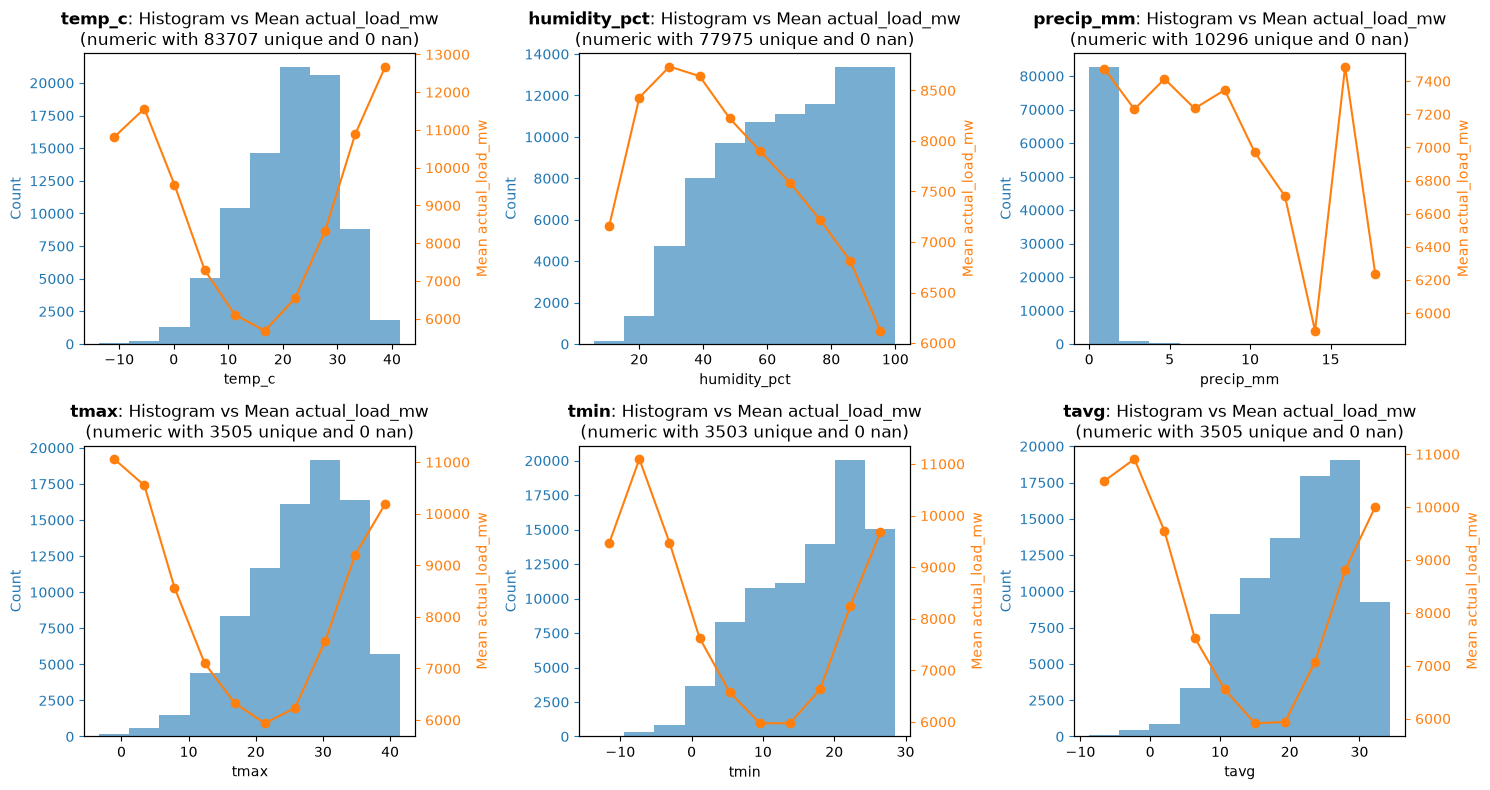

In [17]:
# Create an explicit list of the features you want to plot
# We exclude 'timestamp', 'timestamp_central', and the target itself
features_to_plot = [
    'temp_c', 
    'humidity_pct', 
    'precip_mm', 
    'tmax', 
    'tmin', 
    'tavg'
]

plot_features_dual_axis(
    df_train,                    # Your training dataframe
    cols=features_to_plot,           # The explicit list we just made
    target_col="actual_load_mw",     # Your new target variable
    n_bins=10,                       # Groups temperatures/humidity into 10 buckets
    n_wide=3,                        # Plots 3 charts per row
    int_as_cat_unique_max=20,
    cat_order=None
)

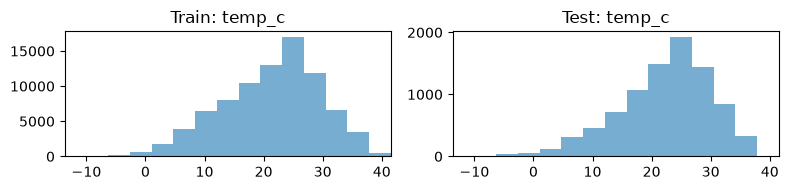

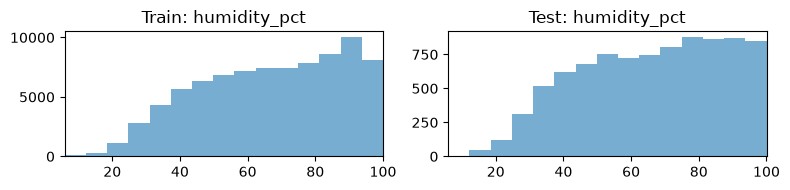

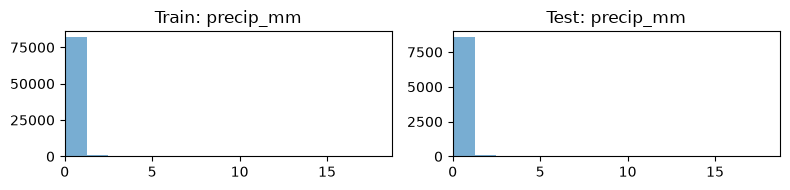

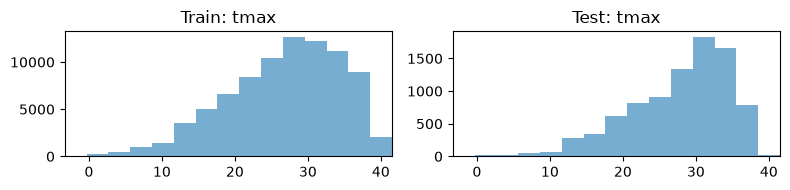

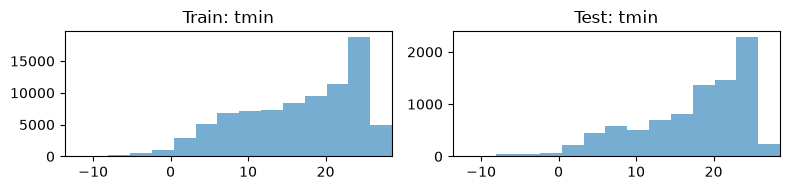

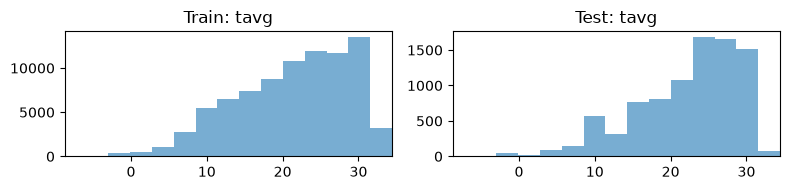

In [20]:
# Explicitly define the weather variables to check for distribution drift
features_to_plot = [
    'temp_c', 
    'humidity_pct', 
    'precip_mm', 
    'tmax', 
    'tmin', 
    'tavg'
]

# Run the distribution comparison
plot_train_test_distributions(
    train=df_train, 
    test=df_test, 
    cols=features_to_plot, 
    n_bins=15
)